***Solving the Travelling Salesman Problem (TSP) using Genetic Algorithm (GA)***

In [1]:
from google.colab import files
uploaded = files.upload()


Saving tsp_dataset.csv to tsp_dataset.csv


In [29]:
import csv
import ast
import random
import math


# ========================== LOAD DATASET ==========================

def load_tsp_instance_from_kaggle(csv_path, instance_index=0):
    with open(csv_path, newline='', encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for idx, row in enumerate(reader):
            if idx == instance_index:
                coords_list = ast.literal_eval(row["city_coordinates"])
                dist_matrix = ast.literal_eval(row["distance_matrix"])
                return {
                    "num_cities": int(row["num_cities"]),
                    "coords": coords_list,
                    "distance_matrix": dist_matrix,
                    "optimal": float(row["total_distance"])
                }
    raise ValueError("Index not found!")

# ========================== TSP HELPER FUNCTIONS (same as PSO) ==========================

def tour_length(tour, dist):
    """
    Compute the total distance of a tour using the distance matrix.
    We also add the edge from the last city back to the first city.
    """
    return sum(dist[tour[i]][tour[(i + 1) % len(tour)]]
               for i in range(len(tour)))


def random_tour(n):
    """
    Create a random permutation of n cities.
    """
    t = list(range(n))
    random.shuffle(t)
    return t


# ========================== GA IMPLEMENTATION ==========================

def init_population(pop_size, n):
    """
    Initialize a population of random tours.
    Each individual is a permutation of n cities.
    """
    return [random_tour(n) for _ in range(pop_size)]


def tournament_selection(population, dist, k=3):
    """
    Tournament selection:
    - Randomly pick k individuals from the population
    - Return the one with the best (lowest) tour length
    """
    candidates = random.sample(population, k)
    best = min(candidates, key=lambda t: tour_length(t, dist))
    return best[:]  # return a copy


def ordered_crossover(parent1, parent2):
    """
    Ordered Crossover (OX) for permutations (TSP).
    Steps:
    1) Choose two random cut points.
    2) Copy the segment from parent1.
    3) Fill remaining positions with cities from parent2 in order, skipping duplicates.
    """
    n = len(parent1)
    child = [None] * n

    # Random crossover points
    i, j = sorted(random.sample(range(n), 2))

    # Copy slice from parent1
    child[i:j+1] = parent1[i:j+1]

    # Fill the rest from parent2
    p2_idx = 0
    for c_idx in range(n):
        if child[c_idx] is None:
            # Find next city in parent2 that is not already in child
            while parent2[p2_idx] in child:
                p2_idx += 1
            child[c_idx] = parent2[p2_idx]
            p2_idx += 1

    return child


def swap_mutation(tour, mutation_rate):
    """
    Swap mutation:
    For each position, with probability mutation_rate,
    swap the city with another random city.
    """
    n = len(tour)
    new_tour = tour[:]
    for i in range(n):
        if random.random() < mutation_rate:
            j = random.randint(0, n - 1)
            new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour


def genetic_algorithm(dist, n,
                      pop_size=50,
                      generations=300,
                      crossover_rate=0.9,
                      mutation_rate=0.1,
                      tournament_k=3):
    """
    Genetic Algorithm (GA) for the Travelling Salesman Problem (TSP).

    Representation:
    - Each individual is a tour (permutation of cities 0..n-1).

    Operators:
    - Selection: Tournament selection
    - Crossover: Ordered crossover (OX)
    - Mutation: Swap mutation

    Parameters
    ----------
    dist : 2D list
        Distance matrix dist[i][j] between city i and j.
    n : int
        Number of cities.
    pop_size : int
        Number of individuals in the population.
    generations : int
        Number of GA generations.
    crossover_rate : float
        Probability of applying crossover.
    mutation_rate : float
        Probability of mutating each position in a tour.
    tournament_k : int
        Tournament size for parent selection.

    Returns
    -------
    best_tour : list[int]
        Best tour found by GA.
    best_distance : float
        Length of the best tour.
    history_ga : list[float]
        History of the best fitness per generation.
    """

    # 1) Initialize population
    population = init_population(pop_size, n)

    # Track global best
    best_tour = None
    best_distance = float("inf")
    history_ga = []

    # ------------------ GA main loop ------------------ #
    for g in range(generations):
        # Evaluate population
        evaluated = [(ind, tour_length(ind, dist)) for ind in population]
        evaluated.sort(key=lambda x: x[1])  # sort by distance (ascending)

        # Update global best
        if evaluated[0][1] < best_distance:
            best_distance = evaluated[0][1]
            best_tour = evaluated[0][0][:]

        history_ga.append(best_distance)

        # Elitism: keep the best individual
        new_population = [best_tour[:]]

        # Generate rest of the population
        while len(new_population) < pop_size:
            # --- Selection ---
            parent1 = tournament_selection(population, dist, k=tournament_k)
            parent2 = tournament_selection(population, dist, k=tournament_k)

            # --- Crossover ---
            if random.random() < crossover_rate:
                child1 = ordered_crossover(parent1, parent2)
                child2 = ordered_crossover(parent2, parent1)
            else:
                child1, child2 = parent1[:], parent2[:]

            # --- Mutation ---
            child1 = swap_mutation(child1, mutation_rate)
            child2 = swap_mutation(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < pop_size:
                new_population.append(child2)

        # Replace old population
        population = new_population

    return best_tour, best_distance, history_ga


In [33]:
# ========================== MAIN EXPERIMENT ==========================
import time

csv_path = "tsp_dataset.csv"

# Shared GA settings
POP_SIZE = 50
GENERATIONS = 300

# List of instances you want to test
instances_to_test = [0, 1]

for instance_index in instances_to_test:
    # Load this instance
    data = load_tsp_instance_from_kaggle(csv_path, instance_index=instance_index)
    n = data["num_cities"]
    dist = data["distance_matrix"]

    # Run GA and measure time
    start_ga = time.time()
    best_ga_tour, best_ga_fit, history_ga = genetic_algorithm(
        dist,
        n,
        pop_size=POP_SIZE,
        generations=GENERATIONS
    )
    end_ga = time.time()
    time_ga = end_ga - start_ga

    # Print results for this instance
    print("\n=================== GA Results ====================")
    print("Instance index:", instance_index)
    print("Optimal (from dataset):", data["optimal"])
    print("GA Best distance found:", best_ga_fit)
    print("GA Best tour:", best_ga_tour)
    print("GA Execution time (s):", time_ga)



=================== GA Results ====================
Instance index: 0
Optimal (from dataset): 2966.177188233671
GA Best distance found: 2117.722026908142
GA Best tour: [24, 46, 32, 42, 39, 34, 40, 54, 27, 28, 29, 33, 31, 44, 38, 10, 26, 37, 35, 16, 3, 49, 5, 20, 9, 13, 36, 11, 7, 6, 1, 14, 4, 0, 15, 19, 45, 47, 21, 50, 41, 8, 25, 43, 48, 53, 22, 2, 52, 51, 17, 30, 12, 23, 18]
GA Execution time (s): 1.7937195301055908

=================== GA Results ====================
Instance index: 1
Optimal (from dataset): 2170.736410510506
GA Best distance found: 1146.1822145739984
GA Best tour: [18, 9, 29, 14, 8, 7, 17, 15, 12, 35, 10, 21, 32, 0, 4, 5, 16, 30, 26, 28, 19, 13, 20, 25, 6, 11, 27, 2, 3, 23, 34, 33, 24, 22, 1, 31, 36]
GA Execution time (s): 0.6989142894744873


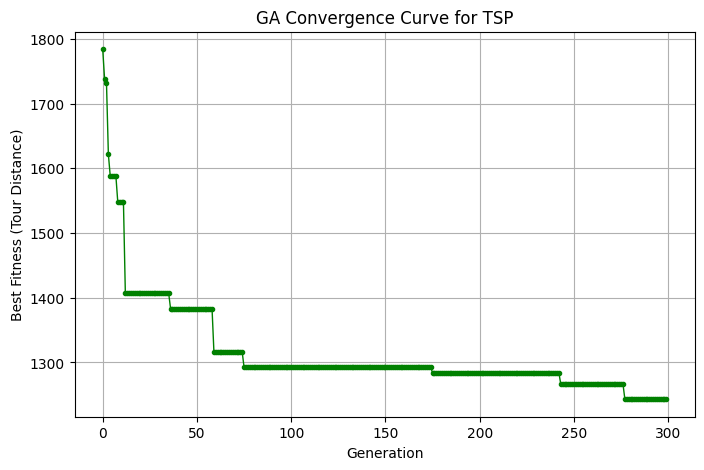

In [32]:
import matplotlib.pyplot as plt
# Convergence curve
plt.figure(figsize=(8, 5))
plt.plot(history_ga, marker='o', markersize=3, linewidth=1, color='green')
plt.title("GA Convergence Curve for TSP")
plt.xlabel("Generation")
plt.ylabel("Best Fitness (Tour Distance)")
plt.grid(True)
plt.show()
